# Diffusion Models

## Start with the problem: turn an easy corruption process into a learning task

Imagine taking an observation and mixing it with a known amount of Gaussian noise. Creating the corrupted observation is easy because we choose the clean input, noise, and mixing rule. Recovering useful structure from a noisy observation is harder because the clean input is not available to the network at prediction time.

A **diffusion model** uses a sequence of noise levels and a learned reverse process. Training creates noisy examples and denoising targets. Generation starts from a defined noisy prior and repeatedly applies a specified reverse sampler.

The distinction matters: a noise-prediction network by itself is not a complete generative sampler. The noise-level convention, reverse mean, variance, step schedule, and terminal conditions must also be defined.

We will calculate forward corruption, predict a noise target, estimate clean content, and work one illustrative reverse step. The [code companion](40_Diffusion_Models.ipynb) verifies one scalar noising equation and trains a tiny two-dimensional noise predictor. Its second project implements a discrete DDPM schedule and a complete reverse sampler after validation-selected training. [Generative Modeling Foundations](37_Generative_Modeling_Foundations_Notes.ipynb) supplies the distribution context.


<div style="background:#FEF3C7;border-left:6px solid #D97706;padding:14px;border-radius:8px"><b>Two stages in the companion.</b> The existing hand calculations and shape/parameter tables describe the opening mechanics example. The complete project at the end uses a separate model and data protocol, summarized below.</div>


## Follow the training example from clean data to a known noise label

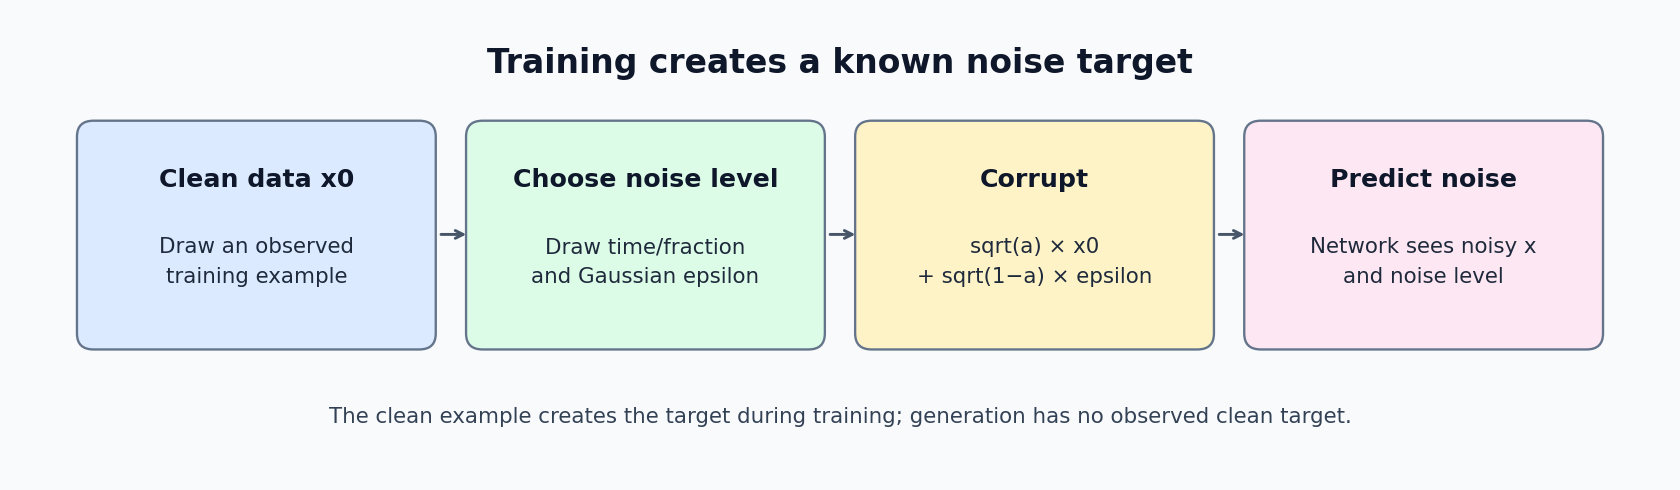

A common forward marginal is:

$$x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\epsilon,\qquad\epsilon\sim\mathcal N(0,I).$$

| Symbol | Meaning |
| --- | --- |
| $x_0$ | Observed clean training example |
| $t$ | Chosen discrete diffusion step in a scheduled formulation |
| $\bar\alpha_t$ | Cumulative signal factor |
| $\epsilon$ | Sampled standard-normal noise |
| $x_t$ | Noisy observation supplied to the predictor |
| $\epsilon_\theta(x_t,t)$ | Network's estimated noise |

The training process knows the sampled noise and can use it as a target. The network sees the noisy input and its noise level, not the clean input as an extra feature in this setup.

The sampled noise has the same coordinate shape as the clean observation. For a two-dimensional example it is a two-vector; for an image it can be an image-shaped tensor.


## Distinguish one-step retention from cumulative retention

A discrete Gaussian forward chain can use $\beta_t\in(0,1)$ and $\alpha_t=1-\beta_t$:

$$x_t=\sqrt{\alpha_t}\,x_{t-1}+\sqrt{\beta_t}\,\eta_t,$$

where fresh $\eta_t$ is standard-normal noise. Its cumulative factor is $\bar\alpha_t=\prod_{s=1}^t\alpha_s$, with $\bar\alpha_0=1$.

For an illustrative two-step schedule:

| Step | $\beta_t$ | $\alpha_t$ | $\bar\alpha_t$ |
| --- | --- | --- | --- |
| 1 | 0.10 | 0.90 | 0.90 |
| 2 | 0.20 | 0.80 | 0.72 |

The second step's retained fraction is 0.80, while cumulative retention is 0.72. Substituting 0.80 into the clean-to-step-two marginal would represent the wrong noise level.

The closed-form marginal lets training draw a chosen $x_t$ directly from $x_0$ without explicitly computing every earlier step. Its noise draw summarizes the accumulated noise distribution; it is not necessarily one of the chain's individual $\eta_t$ draws.

The classic scheduled formulation is detailed in [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239).


## Work the companion's scalar corruption completely

Choose clean value $x_0=2$, cumulative factor $\bar\alpha=0.81$, and selected noise $\epsilon=-1$.

| Part | Calculation | Result |
| --- | --- | --- |
| Signal coefficient | $\sqrt{0.81}$ | 0.9 |
| Noise coefficient | $\sqrt{0.19}$ | 0.435889 |
| Signal contribution | $0.9(2)$ | 1.8 |
| Noise contribution | $0.435889(-1)$ | -0.435889 |
| Noisy value | $1.8-0.435889$ | 1.364110 |

The noise contribution happens to be negative because of this selected draw. Another draw at the same level can raise the observation instead.

The coefficients are square roots. Using $0.81x_0+0.19\epsilon$ would produce a different mean and variance. Also, “19% noise variance” does not mean every individual sample's noise contribution has magnitude 0.19.

Conditional on a fixed clean value, the noisy observation has mean $\sqrt{\bar\alpha}x_0$ and variance $1-\bar\alpha$. A finite sample is one outcome from that conditional distribution.


## See how signal and noise coefficients vary

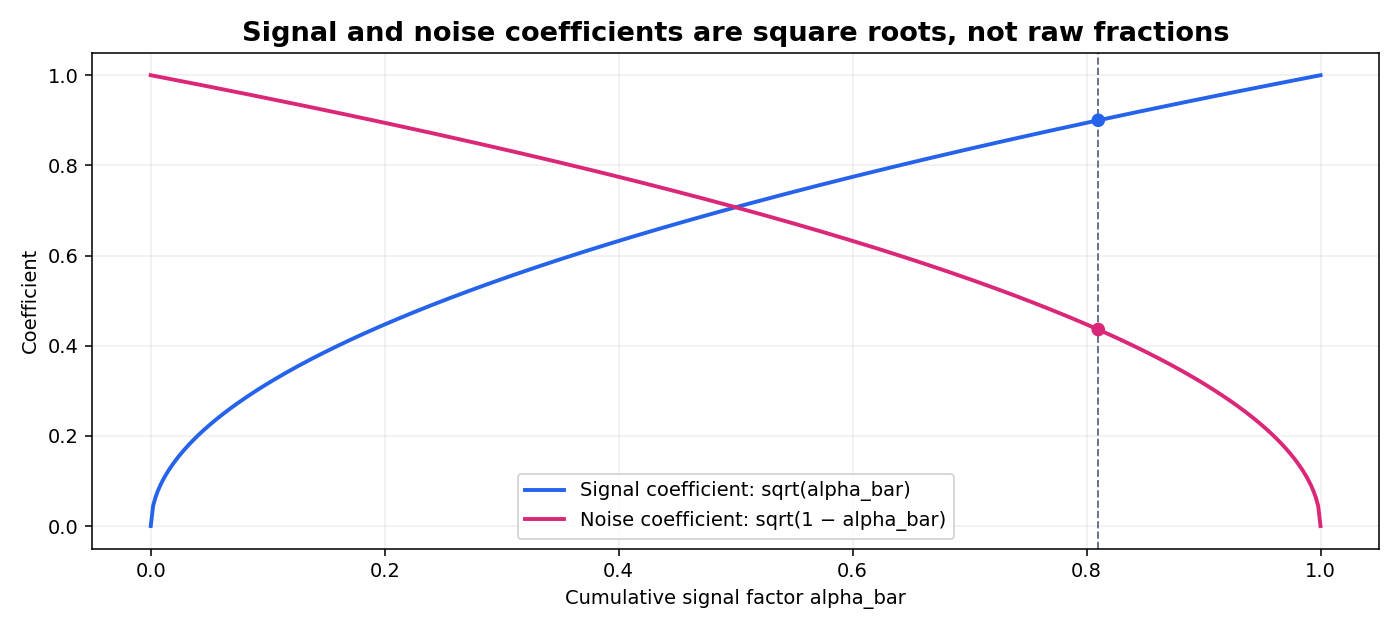

| Cumulative factor | Signal coefficient | Noise coefficient |
| --- | --- | --- |
| 0.81 | 0.9 | 0.435889 |
| 0.25 | 0.5 | 0.866025 |
| 0.01 | 0.1 | 0.994987 |

The squared coefficients sum to one. This does not mean the noisy data always has unit variance, because the clean data may have a different variance and a nonzero mean.

For a clean scalar with mean $m$ and variance $v$, independent noise gives mean $\sqrt{\bar\alpha}m$ and variance $\bar\alpha v+(1-\bar\alpha)$. As cumulative retention becomes small, this tends toward zero mean and unit variance.

For the companion's coordinate variance 0.36 and factor 0.81, noisy variance is $0.81(0.36)+0.19=0.4816$. Its coordinate means $[1,-1]$ become $[0.9,-0.9]$.

A terminal factor that remains large leaves substantial source structure. Starting generation from standard normal then requires more than simply declaring that level terminal.


## Interpret the companion's continuous noise fraction correctly

The companion's training loop draws a scalar `step` uniformly between zero and one and forms:

$$x_s=\sqrt{1-s}\,x_0+\sqrt{s}\,\epsilon.$$

Here $s$ is a **noise fraction**, corresponding to $\bar\alpha=1-s$. It is not a discrete timestep index into an explicitly stored beta schedule.

| Companion noise fraction $s$ | Corresponding cumulative factor | Interpretation |
| --- | --- | --- |
| 0.19 | 0.81 | Matches the scalar check's coefficients |
| 0.75 | 0.25 | More noise than signal by squared coefficients |
| 0.99 | 0.01 | Nearly standard-noise input |

The network receives the noisy two-vector concatenated with this scalar fraction. That is a simple conditioning interface for the teaching example.

Replacing $s$ with $\bar\alpha$ without changing the noising formula or network convention would invert the intended interpretation. A sampler for this trained predictor would need to supply the same meaning of noise level it saw during training.


## Train against noise with a specified mean squared error

A simple noise-prediction objective is:

$$L=\mathbb E_{x_0,t,\epsilon}\left[\|\epsilon-\epsilon_\theta(x_t,t)\|^2\right],$$

with a defined reduction over batch and coordinates. The companion uses mean squared error over both.

For true two-coordinate noise $[-1,0.5]$ and prediction $[-0.8,0.2]$:

| Coordinate | True noise | Prediction | Error | Squared error |
| --- | --- | --- | --- | --- |
| 0 | -1 | -0.8 | 0.2 | 0.04 |
| 1 | 0.5 | 0.2 | -0.3 | 0.09 |

The coordinate mean loss is 0.065. Its prediction gradients are $[0.2,-0.3]$. Treating them as adjustable output biases, a learning-rate-0.1 SGD step gives predictions $[-0.82,0.23]$ and loss 0.05265.

The target is noise, not the noisy observation or clean observation. Other parameterizations can be trained, but their labels and reverse conversions differ. A finite loss on the wrong target would establish a different task.


## Explain why noise prediction can remain uncertain

A noisy input does not uniquely reveal the clean observation and the random noise that produced it. Several clean/noise pairs can yield the same $x_t$. The network must use learned distributional structure and the supplied level to estimate a useful noise value.

Under squared error, an ideal predictor estimates a conditional mean of the noise given the available input and level. It need not recover the exact sampled noise on every example when the conditional distribution has residual uncertainty.

| Noise regime | Question for evaluation |
| --- | --- |
| Low noise | Does the predictor preserve fine structure? |
| Intermediate noise | Does it learn useful data-dependent denoising? |
| High noise | Does it handle ambiguous structure and prior-like inputs? |

A single aggregate MSE can hide poor performance at particular levels. Compare held-out noise-prediction error across level ranges, and separately evaluate any generated samples from an actual sampler.

This is a supervised target created from data and random corruption. It does not require a learned discriminator, but the absence of an adversarial opponent does not itself guarantee reliable generation.


## Estimate clean content from a noise prediction

For $0<\bar\alpha_t<1$, rearrange the forward relation:

$$\hat x_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\hat\epsilon}{\sqrt{\bar\alpha_t}}.$$

Using noisy value 1.364110 from the scalar example and predicted noise -0.8:

$$\hat x_0=\frac{1.364110-0.435889(-0.8)}{0.9}\approx1.903136.$$

With the exact selected noise -1, the formula recovers clean value two. The exact-noise calculation is an oracle check, not an inference guarantee for a learned network.

The clean-estimate error caused by noise-estimate error is:

$$\hat x_0-x_0=-\sqrt{\frac{1-\bar\alpha_t}{\bar\alpha_t}}(\hat\epsilon-\epsilon).$$

At very small cumulative retention, this factor can amplify noise-estimation errors. A one-shot clean estimate at a noisy level is therefore not automatically a substitute for a well-defined iterative sampler.

The formula's denominator also requires care at the zero-signal endpoint. Noise-level conventions and endpoint handling are part of the computation, not cosmetic notation.


## Specify a reverse step rather than subtracting raw noise arbitrarily

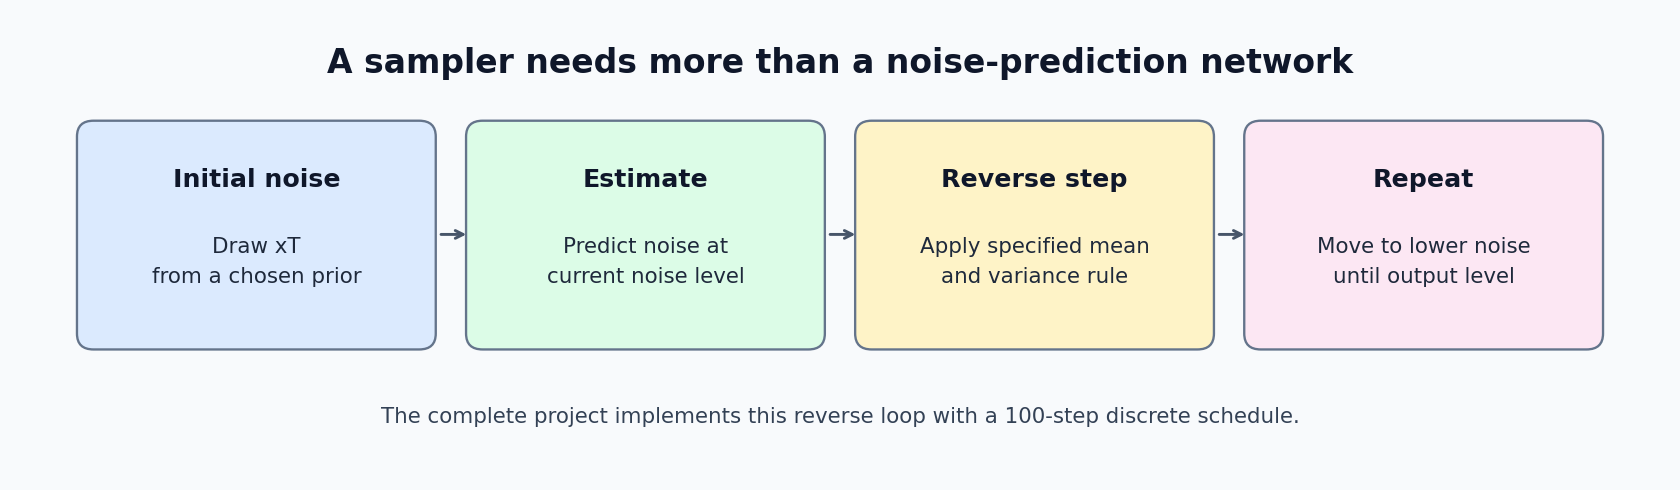

For a classic discrete epsilon-parameterized reverse step, one mean is:

$$\mu_\theta(x_t,t)=\frac1{\sqrt{\alpha_t}}\left(x_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\epsilon_\theta(x_t,t)\right).$$

A selected ancestral sampling rule draws $x_{t-1}=\mu_\theta+\sigma_t\xi$, with fresh standard-normal $\xi$. One variance choice is $\sigma_t^2=\tilde\beta_t=\beta_t(1-\bar\alpha_{t-1})/(1-\bar\alpha_t)$; other choices and samplers define different procedures.

For the illustrative two-step schedule, take $x_0=2$, cumulative noise draw -1, and step two. Then $x_2=\sqrt{0.72}(2)-\sqrt{0.28}\approx1.167906$. Select predicted noise -1 at this step.

| Reverse quantity | Result |
| --- | --- |
| Step-two mean | 1.728336 |
| Chosen variance $\tilde\beta_2$ | 0.071429 |
| Chosen standard deviation | 0.267261 |
| Reverse sample with selected $\xi=0$ | 1.728336 |

This sample is at level one, not the final clean output. The two-step example is deliberately too short to justify a Gaussian terminal approximation at retention 0.72. It illustrates the reverse arithmetic, not a complete learned generation experiment.


## Trace the exact companion predictor and training loop

The companion generates 256 clean two-vectors with mean $[1,-1]$ and coordinate standard deviation 0.6. Each of 80 Adam updates samples a batch of 64 clean observations, a fresh noise fraction, and fresh Gaussian noise.

| Object or module | Shape | Parameters |
| --- | --- | --- |
| Clean/noisy/noise batch | $(64,2)$ | None |
| Noise fraction | $(64,1)$ | None |
| Concatenated network input | $(64,3)$ | None |
| Linear $3\to32$ | $(64,32)$ | 128 |
| Tanh | $(64,32)$ | None |
| Linear $32\to2$ | $(64,2)$ | 66 |

The predictor has 194 parameters. Adam uses learning rate 0.01. The code clears gradients, computes the noise-prediction loss, backpropagates, and updates the network.

Its scalar verification uses float64 to inspect the noising result; the small training example uses the ordinary tensors created in that loop. The important interface is that both noise coordinates are predicted from two noisy coordinates plus one supplied level.

No reverse sampling loop or generated-distribution evaluation is present. The finite-loss assertion establishes a calculable training objective, not samples from a learned diffusion distribution.


## Distinguish training, reconstruction, and generation

| Operation | Starting information | Needed procedure |
| --- | --- | --- |
| Noise-prediction training | Clean data and sampled noise | Create noisy examples and fit target noise |
| Noisy-input clean estimation | A noisy observation and level | Predict noise and convert to a clean estimate |
| Unconditional generation | Initial prior noise | Run a defined reverse schedule |
| Conditional generation | Prior noise plus supplied condition | Train and sample a condition-aware predictor |

For conditional generation, a condition can be supplied through features or attention, but the network must learn the associated relationship. A prompt or class ID is not automatically meaningful to an untrained predictor.

Diffusion can also operate in a learned latent representation rather than directly in image pixels. Such a system includes an encoder/decoder representation contract in addition to its noising and reverse procedures. The companion uses raw two-dimensional vectors and contains no latent image model.

These distinctions keep an attractive denoised example from being mistaken for evidence that a complete unconditional sampler has been implemented and assessed.


## Evaluate the predictor and the sampler separately

Held-out denoising error asks whether the learned predictor estimates noise on independent corrupted examples. Generated-sample quality asks whether the complete reverse procedure produces the intended distribution. A sampling schedule can change output behavior even when the network weights are fixed.

| Evaluation item | Useful evidence |
| --- | --- |
| Noise predictor | Error by level on held-out clean examples and fresh noise |
| Numerical reverse procedure | Verified schedule, conversions, and endpoint handling |
| Generated distribution | Independent moments, shape, and coverage |
| Conditional behavior | Held-out conditions and adherence checks |
| Resource use | Measured network calls, latency, and memory |

The two-dimensional target makes mean, covariance, and density-shape comparisons straightforward once a sampler exists. The opening continuous-fraction example does not generate samples. The complete discrete-schedule project now produces fresh samples and compares their mode coverage, spread, and distances with the defined distribution.

Sampling can require many network calls. Reducing calls changes the solver or schedule and requires a new quality comparison, not just a declaration that denoising became faster without tradeoffs.


## Diagnose noise-level and objective mistakes

| Mistake | Consequence | Check |
| --- | --- | --- |
| Confuse $\alpha_t$ with $\bar\alpha_t$ | Wrong cumulative corruption | Product across the schedule |
| Confuse noise fraction with retention | Reversed level conditioning | Companion uses $s=1-\bar\alpha$ |
| Omit square roots in mixing | Wrong mean and variance | Forward coefficients |
| Train on clean values while interpreting outputs as noise | Wrong conversion at inference | Target parameterization |
| Start at a non-Gaussian terminal with pure noise | Mismatched initial distribution | Terminal retention and training support |
| Call a predictor a complete sampler | Missing reverse-generation evidence | Locate actual reverse loop |

A shape check can verify that two outputs are produced, but cannot reveal an inverted time convention. Small scalar calculations like the companion's first example are valuable because they expose the meaning of the coefficients before a larger network obscures it.


## Practice the corruption and retain the reverse contract

1. With clean value two, cumulative retention 0.25, and selected noise zero, what is the noisy value?
2. Which cumulative retention corresponds to the companion's noise fraction 0.8?
3. Does exact selected noise recover $x_0$ through the stated inversion when retention is positive?
4. How many parameters are in the companion predictor?
5. Does its saved code generate samples through a reverse loop?

**Answers.** The noisy value is $\sqrt{0.25}(2)=1$. Noise fraction 0.8 corresponds to retention 0.2. Exact selected noise recovers the clean value in the algebraic check, but a learned predictor is not guaranteed to know it exactly. The predictor has 194 parameters. The opening predictor has 194 parameters and trains noise prediction only; the second project uses a separate denoiser and runs the full reverse chain.

**Remember:** forward corruption creates a known target, noise-conditioned training learns a predictor, and a specified reverse sampler turns that predictor into a generation procedure. Each stage has its own assumptions and evidence.

Continue with [Language Model Foundations](41_Language_Model_Foundations_Notes.ipynb), which connects tokenization, conditional probabilities, training loss, and sequence generation.


## Complete project walkthrough: discrete diffusion and fresh sampling

<div style="background:#EDE9FE;border-left:6px solid #7C3AED;padding:16px;border-radius:8px"><b>The reverse chain is now implemented.</b> The companion's second project trains a separate denoiser under a defined discrete schedule, restores a validation-selected checkpoint, and generates 1,024 fresh points from standard-normal initial noise.</div>

The target distribution has four equally weighted Gaussian components centered at $(\pm1.5,\pm1.5)$, with coordinate standard deviation 0.25. Separate seeded draws provide 2,048 training, 512 validation, and 512 test points. The same generating distribution is intentional; sample observations are independently drawn.

| Quantity | Complete-project convention |
|---|---|
| Schedule | 100 linearly spaced beta values from 0.0001 to 0.12 |
| Alpha | $\alpha_t=1-\beta_t$ |
| Cumulative retention | Product of alpha values through the current index |
| Terminal retention | Approximately 0.001907 |
| Time representation | Four sine/cosine frequency pairs |
| Denoiser | `10→64→64→2`, SiLU hidden activations |
| Trainable parameters | 4,994; frequency buffer is not a learned parameter |
| Objective | Mean squared noise-prediction error |

The eight time coordinates accompany the two noisy point coordinates. They encode discrete time; this is distinct from the first example's continuous noise-fraction convention. An index must refer to the same schedule during corruption and reverse sampling.


### Select without inspecting generated test samples

Two thousand updates use batches of 128, Adam at 0.001, and gradient clipping at norm 1.0. Training draws fresh clean indices, time indices, and Gaussian noise. Every fifty updates, validation noise MSE is measured using fixed time/noise draws. This reduces comparison noise and supplies the checkpoint rule. Deep-copy the best state and restore it before sampling.

Final test MSE uses separate test observations and corruption draws. A zero-noise predictor is a simple predictive baseline. Test noise MSE evaluates the denoising objective; it is not a direct measure of generated distribution quality.


### Run every reverse transition

Begin with $x_T\sim\mathcal N(0,I)$. For each schedule index in descending order, predict noise and calculate the reverse mean using the current beta, alpha, and cumulative retention. Add noise scaled by the square root of the posterior variance on nonfinal steps. The final transition adds no random noise because its posterior variance is zero.

A selected scalar/vector oracle calculation compares the noise-parameterized mean with the known conditional posterior mean. Sampler assertions verify finite output shape, identical results for identical seeds, and changed outputs for another seed. The trajectory plot follows the same points through several reverse levels; it does not independently resample each panel.

| Distribution check | What it reveals | Limitation |
|---|---|---|
| Sample mean | Overall location | Symmetric collapse can still match it |
| Coordinate standard deviations | Spread | Different shapes can have identical spread |
| Nearest-center proportions | Apparent coverage of four modes | Even outliers are assigned to a mode |
| Mean nearest-center distance | Concentration near target modes | Alone does not measure every distribution feature |
| Scatter and trajectory plots | Shape and reverse evolution | Visual inspection is not a formal equality test |

The population coordinate variance is $1.5^2+0.25^2=2.3125$. Compare observed finite-sample statistics with this reference, allowing sampling variation. The terminal forward distribution is only approximately standard normal because retention is small, not exactly zero. Finite training and the chosen reverse variance also introduce approximation error. The experiment makes these imperfections visible rather than claiming an exact sampler.


## Executed reference run: Discrete diffusion

<div style="background:#DCFCE7;border-left:6px solid #16A34A;padding:14px;border-radius:8px"><b>Measured results.</b> Selected update: 1900. Held-out noise MSE: **0.3041** versus **0.9192** for zero prediction. The reverse sampler produced **1,024 points**. Nearest-mode proportions were approximately **0.290 / 0.256 / 0.212 / 0.242**. Generated mean nearest-center distance: 0.3862, versus 0.3057 on held-out real points; the learned distribution is approximate.</div>

These outputs were obtained by running every code cell in a fresh CPU kernel with the repository’s virtual environment. They describe this fixed synthetic experiment, not performance on arbitrary real-world data.

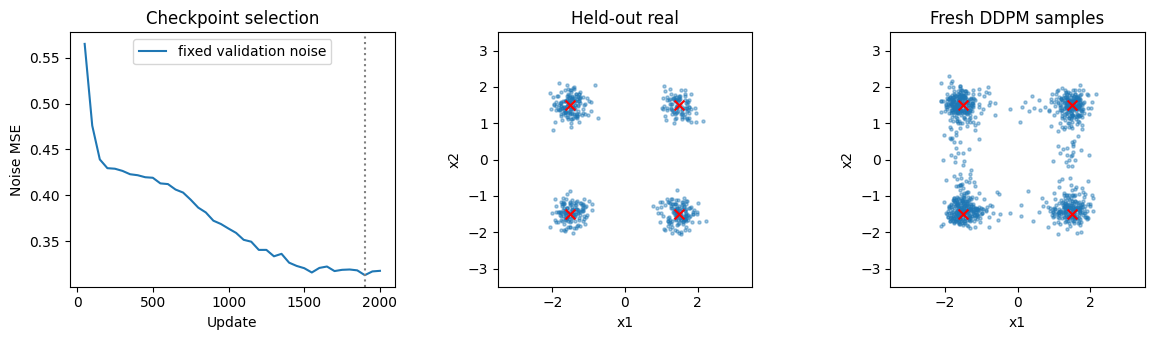

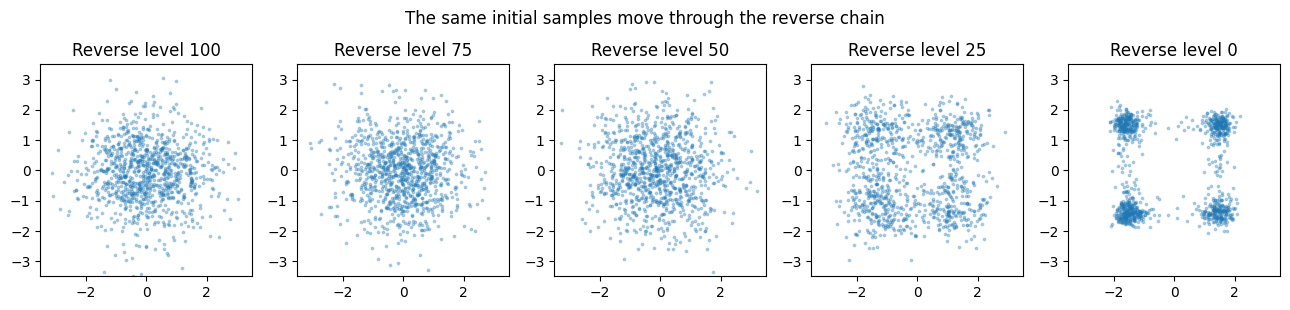
